In [1]:
#| hide
%matplotlib inline
from auto_economics import Free_market, Monopoly, Game

# auto_economics

> Automated Economics

Automate the tedious parts of intro microeconomics: solve for equilibrium, compute consumer/producer surplus, chart supply and demand, and see deadweight loss for a monopoly — all from a supply and demand expression written as plain strings.

## Install

```sh
pip install auto_economics
```

Link: https://pypi.org/project/auto-economics/

## How to use

### Free market: equilibrium, surplus, and a supply-and-demand chart

{'quantity': 5.0, 'price': 5.0}
consumer surplus = 12.50
producer surplus = 12.50
deadweight loss = 0.00


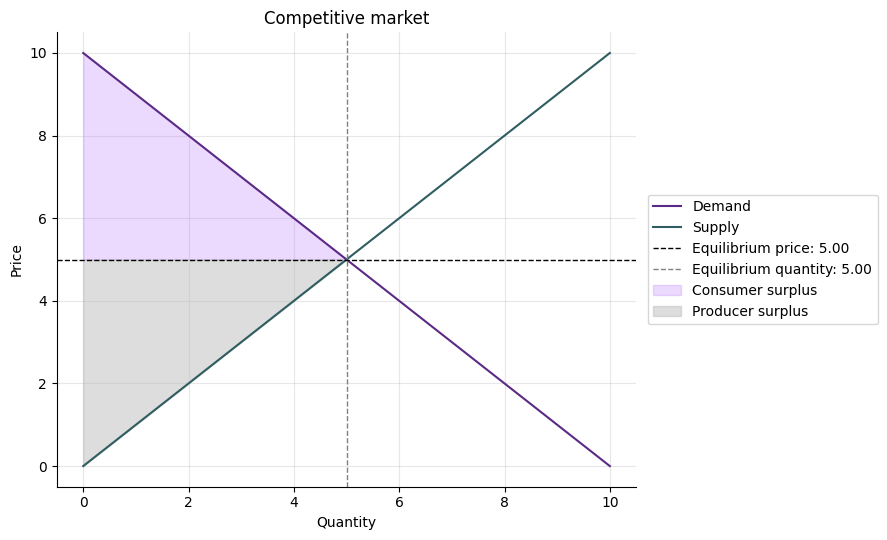

In [2]:
free_market = Free_market(supply="x", demand="10 - x")

print(free_market.equilibrium())
print(f"consumer surplus = {free_market.get_consumer_surplus():.2f}")
print(f"producer surplus = {free_market.get_producer_surplus():.2f}")
print(f"deadweight loss = {free_market.deadweight_loss():.2f}")

free_market.plot(complete=True);

### Monopoly: quantity/price distortion and deadweight loss

Pass the same marginal-cost curve as `supply` to see how a monopolist restricts output relative to the competitive outcome, and the deadweight loss that results.

monopoly equilibrium = {'quantity': 3.3333333333333335, 'price': 6.666666666666666}
competitive equilibrium = {'quantity': 5.0, 'price': 5.0}
deadweight loss = 2.78


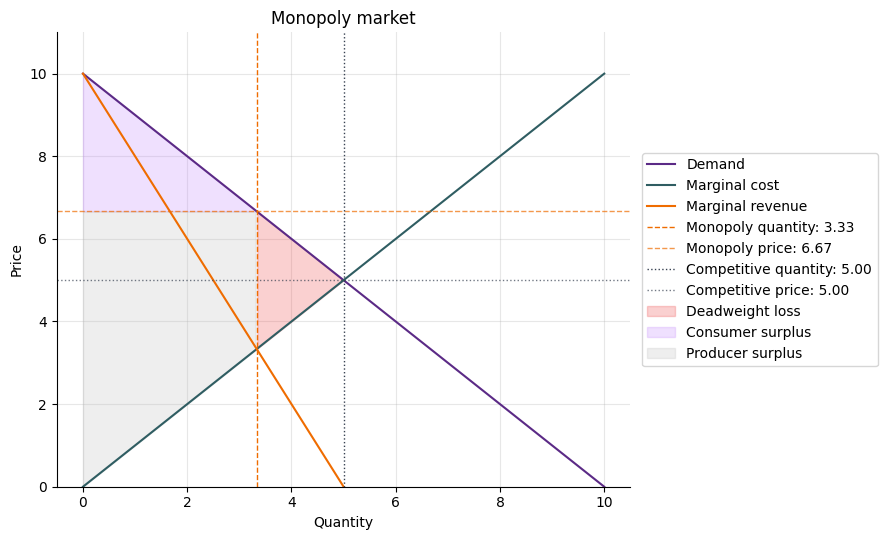

In [3]:
monopoly = Monopoly(supply="x", demand="10 - x")

print(f"monopoly equilibrium = {monopoly.equilibrium()}")
print(f"competitive equilibrium = {monopoly.competitive_equilibrium()}")
print(f"deadweight loss = {monopoly.deadweight_loss():.2f}")

monopoly.plot(complete=True);

### Comparing surplus across market structures

In [4]:
print(f"Consumer surplus free market: {free_market.get_consumer_surplus():.2f}")
print(f"Consumer surplus monopoly:    {monopoly.get_consumer_surplus():.2f}")

print(f"Producer surplus free market: {free_market.get_producer_surplus():.2f}")
print(f"Producer surplus monopoly:    {monopoly.get_producer_surplus():.2f}")

print(f"Economic surplus free market: {free_market.get_economic_surplus():.2f}")
print(f"Economic surplus monopoly:    {monopoly.get_economic_surplus():.2f}")

Consumer surplus free market: 12.50
Consumer surplus monopoly:    5.56
Producer surplus free market: 12.50
Producer surplus monopoly:    16.67
Economic surplus free market: 25.00
Economic surplus monopoly:    22.22


### Game theory: find pure-strategy Nash equilibria

In [5]:
player_1 = {
    "cooperate-cooporate": 3,
    "cooperate-defect": 0,
    "defect-cooporate": 5,
    "defect-defect": -1,
}
player_2 = {
    "cooperate-cooporate": 3,
    "cooperate-defect": 5,
    "defect-cooporate": 0,
    "defect-defect": -1,
}

game = Game(player_1, player_2)
print(f"nash equilibria = {game.find_nash_equilibriums()}")
game.get_game_matrix()

nash equilibria = [('Cooperate', 'Defect'), ('Defect', 'Cooperate')]


,Cooperate,Defect
Cooperate,"3, 3","0, 5"
Defect,"5, 0","-1, -1"


Or as a copy-pasteable image, with the Nash equilibria highlighted:

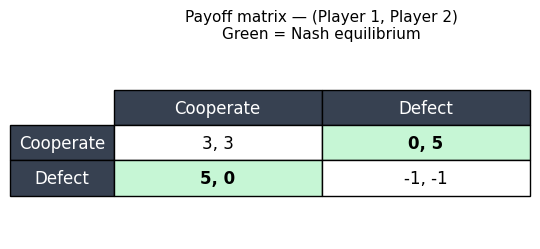

In [6]:
game.plot_matrix();

## Exporting figures for assignments

Every `plot`/`plot_matrix`/`get_graph` call accepts `save_path` and `dpi`, so you can write a crisp PNG or SVG straight to disk instead of copying a screenshot:

```python
free_market.plot(complete=True, show=False, save_path="free_market.svg")
monopoly.plot(complete=True, show=False, save_path="monopoly.png", dpi=300)
game.plot_matrix(show=False, save_path="payoff_matrix.png")
```

## Supply and demand expressions

`supply` and `demand` accept any expression in the quantity variable `x` — a linear string like `"10 - x"`, a `sympy` expression, or a plain number for a constant curve.